# 01 — Exploración inicial (NuDat 3)

**Objetivo:** conocer la estructura de los CSV originales con Python/Pandas: registros, variables, tipos, faltantes, duplicados, rangos, atípicos y relaciones físicas, con visualizaciones interpretadas.

 ¿cómo evoluciona $N/Z$ frente al modo dominante ($\beta^-$ vs $\beta^+$/EC), cuál es la correlación entre $Q_\beta$ y la vida media, y cómo se sitúa respecto al valle (BE/A, residual LDM)?

**Datos:** `data/raw/` (sin modificar). Fuente: [NuDat 3](https://www.nndc.bnl.gov/nudat3/).

> Esta notebook es **solo exploración**. La limpieza y el join van en `02_clean_etl.ipynb`.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)

ROOT = Path("..").resolve()
if not (ROOT / "data" / "raw").exists():
    ROOT = Path(".").resolve()
RAW = ROOT / "data" / "raw"
FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)

print("RAW =", RAW)
print("Archivos:", sorted(p.name for p in RAW.glob("*.csv")))


RAW = /home/isabel/nudat3-decay-stability/data/raw
Archivos: ['nndc_nudat_data_export (10).csv', 'nndc_nudat_data_export (12).csv', 'nndc_nudat_data_export (21).csv', 'walletcards.csv']


## 1. Carga de los cuatro CSV canónicos

Leemos cada archivo por separado para inspeccionar su estructura antes de cualquier join.

In [2]:
wallet = pd.read_csv(RAW / "walletcards.csv")
hl = pd.read_csv(RAW / "nndc_nudat_data_export (10).csv")
qbe = pd.read_csv(RAW / "nndc_nudat_data_export (12).csv")
pair = pd.read_csv(RAW / "nndc_nudat_data_export (21).csv")

datasets = {
    "walletcards": wallet,
    "export_10_halflife": hl,
    "export_12_Q_BE": qbe,
    "export_21_pairing_alpha": pair,
}

summary = pd.DataFrame([
    {
        "dataset": name,
        "n_filas": len(df),
        "n_columnas": df.shape[1],
        "memoria_MB": round(df.memory_usage(deep=True).sum() / 1e6, 2),
    }
    for name, df in datasets.items()
])
summary


,dataset,n_filas,n_columnas,memoria_MB
0,walletcards,4116,25,2.58
1,export_10_halflife,3150,3,0.23
2,export_12_Q_BE,4106,13,0.61
3,export_21_pairing_alpha,4106,16,0.71


### Interpretación

- **Wallet Cards** (~4100 filas) incluye estados base e isómeros (`Level Index`).
- Los exports del Chart (~3100–4100) van por nuclido $(Z,N)$.
- No hay componente temporal: es un *snapshot* evaluado (ENSDF / AME / Wallet), no una serie de tiempo.

## 2. Estructura, tipos y variables numéricas vs categóricas

In [3]:
def describe_structure(name: str, df: pd.DataFrame) -> None:
    print("=" * 72)
    print(name)
    print("=" * 72)
    print("Columnas:", list(df.columns))
    print()
    print(df.dtypes)
    print()
    num = df.select_dtypes(include=[np.number]).columns.tolist()
    cat = df.select_dtypes(exclude=[np.number]).columns.tolist()
    print(f"Numéricas ({len(num)}):", num)
    print(f"No numéricas / categóricas ({len(cat)}):", cat)
    print()
    display(df.head(3))

for name, df in datasets.items():
    describe_structure(name, df)


walletcards
Columnas: ['Atomic Number (Z)', 'Atomic Mass (A)', 'Level Index', 'Element', 'Level Energy (Modifier)', 'Level Energy', 'Level Energy (Unit)', 'Level Energy (Error)', 'Spin-Parity', 'Half-Life (Modifier)', 'Half-Life', 'Half-Life (Unit)', 'Half-Life (Error)', 'Decay Width (Modifier)', 'Decay Width', 'Decay Width (Unit)', 'Decay Width (Error)', 'Abundance (Modifier)', 'Abundance', 'Abundance (Error)', 'Mass Excess', 'Mass Excess (Unit)', 'Mass Excess (Error)', 'Decay Modes', 'Unnamed: 24']

Atomic Number (Z)            int64
Atomic Mass (A)              int64
Level Index                  int64
Element                        str
Level Energy (Modifier)    float64
Level Energy               float64
Level Energy (Unit)            str
Level Energy (Error)       float64
Spin-Parity                    str
Half-Life (Modifier)           str
Half-Life                      str
Half-Life (Unit)               str
Half-Life (Error)              str
Decay Width (Modifier)     float64
Dec

,Atomic Number (Z),Atomic Mass (A),Level Index,Element,Level Energy (Modifier),Level Energy,Level Energy (Unit),Level Energy (Error),Spin-Parity,Half-Life (Modifier),Half-Life,Half-Life (Unit),Half-Life (Error),Decay Width (Modifier),Decay Width,Decay Width (Unit),Decay Width (Error),Abundance (Modifier),Abundance,Abundance (Error),Mass Excess,Mass Excess (Unit),Mass Excess (Error),Decay Modes,Unnamed: 24
0,0,1,0,NN,NaN,0.0,keV,NaN,1/2+,NaN,608.9,s,0.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8071.318060,keV,0.000440,B- = 100,NaN
1,1,1,0,H,NaN,0.0,keV,NaN,1/2+,NaN,STABLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.9855,NaN,7288.971064,keV,0.000013,NaN,NaN
2,1,2,0,H,NaN,0.0,keV,NaN,1+,NaN,STABLE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0145,NaN,13135.722895,keV,0.000015,NaN,NaN


export_10_halflife
Columnas: ['z', 'n', 'halflife(Seconds)']

z                    int64
n                    int64
halflife(Seconds)      str
dtype: object

Numéricas (2): ['z', 'n']
No numéricas / categóricas (1): ['halflife(Seconds)']



,z,n,halflife(Seconds)
0,1,0,STABLE
1,1,1,STABLE
2,2,1,STABLE


export_12_Q_BE
Columnas: ['z', 'n', 'name', 'betaMinus', 'betaMinusUncertainty', 'electronCapture', 'electronCaptureUncertainty', 'positronEmission', 'positronEmissionUncertainty', 'bindingEnergy', 'bindingEnergyUncertainty', 'bindingEnergyLDMFit', 'bindingEnergyLDMFitUncertainty']

z                                   int64
n                                   int64
name                                  str
betaMinus                         float64
betaMinusUncertainty              float64
electronCapture                   float64
electronCaptureUncertainty        float64
positronEmission                  float64
positronEmissionUncertainty       float64
bindingEnergy                     float64
bindingEnergyUncertainty          float64
bindingEnergyLDMFit               float64
bindingEnergyLDMFitUncertainty    float64
dtype: object

Numéricas (12): ['z', 'n', 'betaMinus', 'betaMinusUncertainty', 'electronCapture', 'electronCaptureUncertainty', 'positronEmission', 'positronEmissionUncer

,z,n,name,betaMinus,betaMinusUncertainty,electronCapture,electronCaptureUncertainty,positronEmission,positronEmissionUncertainty,bindingEnergy,bindingEnergyUncertainty,bindingEnergyLDMFit,bindingEnergyLDMFitUncertainty
0,0,1,Neutron,782.0,0.0004,NaN,NaN,NaN,NaN,0.0,0.0000,-24800.0,0.0000
1,1,0,1H,NaN,NaN,-782.0,0.0004,-1800.0,0.0004,0.0,0.0000,-25500.0,0.0000
2,1,1,2H,NaN,NaN,NaN,NaN,NaN,NaN,1110.0,0.0002,-3760.0,0.0002


export_21_pairing_alpha
Columnas: ['z', 'n', 'name', 'spinAndParity', 'massExcess(keV)', 'massExcessUncertainty', 'neutronSeparationEnergy', 'neutronSeparationEnergyUncertainty', 'protonSeparationEnergy', 'protonSeparationEnergyUncertainty', 'pairingGap', 'pairingGapUncertainty', 'alpha', 'alphaUncertainty', 'deltaAlpha', 'deltaAlphaUncertainty']

z                                       int64
n                                       int64
name                                      str
spinAndParity                         float64
massExcess(keV)                       float64
massExcessUncertainty                 float64
neutronSeparationEnergy               float64
neutronSeparationEnergyUncertainty    float64
protonSeparationEnergy                float64
protonSeparationEnergyUncertainty     float64
pairingGap                            float64
pairingGapUncertainty                 float64
alpha                                 float64
alphaUncertainty                      float64
deltaA

,z,n,name,spinAndParity,massExcess(keV),massExcessUncertainty,neutronSeparationEnergy,neutronSeparationEnergyUncertainty,protonSeparationEnergy,protonSeparationEnergyUncertainty,pairingGap,pairingGapUncertainty,alpha,alphaUncertainty,deltaAlpha,deltaAlphaUncertainty
0,0,1,Neutron,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,0,1H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1,2H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010.0,0.000531,NaN,NaN,NaN,NaN


### Interpretación

- En Wallet, varias magnitudes vienen como **texto** (`Half-Life`, `Decay Modes`, `Spin-Parity`) aunque representen cantidades físicas: habrá que parsearlas en la limpieza.
- En Chart, $Q$, BE/A y vidas medias ya vienen numéricas (notación científica), pero Pandas puede leerlas como `object` si hay celdas vacías mezcladas — conviene forzar `to_numeric` al explorar rangos.

## 3. Valores faltantes

In [4]:
def missing_report(df: pd.DataFrame) -> pd.DataFrame:
    miss = df.isna().sum()
    empty_str = (df.astype(str).apply(lambda s: s.str.strip() == "")).sum()
    out = pd.DataFrame({
        "n_na": miss,
        "pct_na": (100 * miss / len(df)).round(1),
        "n_empty_str": empty_str,
    })
    return out[(out["n_na"] > 0) | (out["n_empty_str"] > 0)].sort_values("pct_na", ascending=False)

for name, df in datasets.items():
    print(f"\n### {name}")
    rep = missing_report(df)
    display(rep if len(rep) else pd.DataFrame({"msg": ["sin NA / strings vacíos detectados"]}))



### walletcards


,n_na,pct_na,n_empty_str
Level Energy (Modifier),4116,100.0,0
Abundance (Modifier),4116,100.0,0
Decay Width (Modifier),4116,100.0,0
Unnamed: 24,4116,100.0,0
Half-Life (Modifier),4100,99.6,0
Decay Width (Error),4086,99.3,0
Decay Width,4079,99.1,0
Decay Width (Unit),4079,99.1,0
Abundance (Error),3857,93.7,0
Abundance,3828,93.0,0



### export_10_halflife


,msg
0,sin NA / strings vacíos detectados



### export_12_Q_BE


,n_na,pct_na,n_empty_str
electronCaptureUncertainty,238,5.8,0
electronCapture,238,5.8,0
positronEmission,238,5.8,0
positronEmissionUncertainty,238,5.8,0
betaMinusUncertainty,233,5.7,0
betaMinus,233,5.7,0
bindingEnergy,1,0.0,0
bindingEnergyUncertainty,1,0.0,0
bindingEnergyLDMFit,1,0.0,0
bindingEnergyLDMFitUncertainty,1,0.0,0



### export_21_pairing_alpha


,n_na,pct_na,n_empty_str
spinAndParity,4106,100.0,0
massExcess(keV),4106,100.0,0
massExcessUncertainty,4106,100.0,0
neutronSeparationEnergy,4106,100.0,0
neutronSeparationEnergyUncertainty,4106,100.0,0
protonSeparationEnergy,4106,100.0,0
protonSeparationEnergyUncertainty,4106,100.0,0
deltaAlpha,220,5.4,0
deltaAlphaUncertainty,220,5.4,0
pairingGapUncertainty,158,3.8,0


Fracción no nula — export 21:


,spinAndParity,neutronSeparationEnergy,massExcessUncertainty,massExcess(keV),neutronSeparationEnergyUncertainty,protonSeparationEnergy,protonSeparationEnergyUncertainty,deltaAlpha,deltaAlphaUncertainty,pairingGapUncertainty,pairingGap,alphaUncertainty,alpha,n,name,z
frac_non_null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.94642,0.94642,0.96152,0.96152,0.971262,0.971262,1.0,1.0,1.0


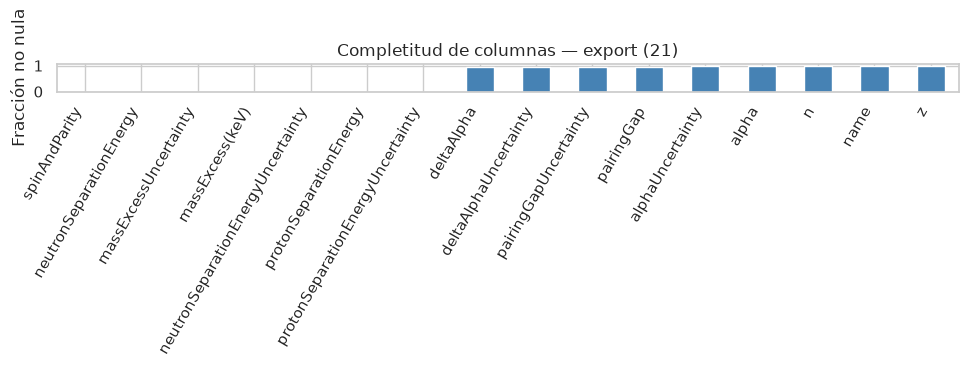

In [5]:
# Export 21: columnas que existen pero están completamente vacías
pair_num = pair.copy()
for c in pair_num.columns:
    if c not in {"z", "n", "name"}:
        pair_num[c] = pd.to_numeric(pair_num[c], errors="coerce")

fill_pair = pair_num.notna().mean().sort_values()
print("Fracción no nula — export 21:")
display(fill_pair.to_frame("frac_non_null").T)

fig, ax = plt.subplots(figsize=(10, 3.5))
fill_pair.plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("Fracción no nula")
ax.set_title("Completitud de columnas — export (21)")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.savefig(FIG / "eda_export21_completitud.png", dpi=120)
plt.show()


### Interpretación física / de calidad

- En Wallet, faltantes en vida media o modos suelen corresponder a resonancias (solo *decay width*) o núcleos muy exóticos.
- En export (21), `spinAndParity`, `massExcess`, $S_n$ y $S_p$ salieron **vacíos** (límite del export NuDat); el spin y mass excess sí están en Wallet.
- Q y BE/A (export 12) tienen buena cobertura; los faltantes en $Q$ son esperables cuando el canal no aplica o no está evaluado.

## 4. Duplicados

In [6]:
print("Wallet duplicados exactos:", wallet.duplicated().sum())
print("Wallet duplicados (Z, A, Level Index):",
      wallet.duplicated(subset=["Atomic Number (Z)", "Atomic Mass (A)", "Level Index"]).sum())

for name, df, keys in [
    ("hl", hl, ["z", "n"]),
    ("qbe", qbe, ["z", "n"]),
    ("pair", pair, ["z", "n"]),
]:
    n_dup = df.duplicated(subset=keys).sum()
    print(f"{name} duplicados en {keys}: {n_dup} (filas={len(df)}, claves únicas={df.drop_duplicates(keys).shape[0]})")


Wallet duplicados exactos: 0
Wallet duplicados (Z, A, Level Index): 0
hl duplicados en ['z', 'n']: 0 (filas=3150, claves únicas=3150)
qbe duplicados en ['z', 'n']: 747 (filas=4106, claves únicas=3359)
pair duplicados en ['z', 'n']: 747 (filas=4106, claves únicas=3359)


### Interpretación

- Wallet está bien indexado por $(Z,A,$ nivel$)$.
- Chart exports (12) y (21) tienen **$(Z,N)$ repetidos** (isómeros listados más de una vez). En la limpieza habrá que deduplicar antes del join.

## 5. Rangos y estadísticas descriptivas

In [7]:
def coerce_numeric(df: pd.DataFrame, cols) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

wallet_n = coerce_numeric(
    wallet,
    ["Atomic Number (Z)", "Atomic Mass (A)", "Level Index",
     "Level Energy", "Abundance", "Mass Excess"],
)
hl_n = coerce_numeric(hl, ["z", "n", "halflife(Seconds)"])
qbe_n = coerce_numeric(
    qbe,
    ["z", "n", "betaMinus", "electronCapture", "positronEmission",
     "bindingEnergy", "bindingEnergyLDMFit"],
)
pair_n = coerce_numeric(
    pair,
    ["z", "n", "pairingGap", "alpha", "deltaAlpha"],
)

display(wallet_n[["Atomic Number (Z)", "Atomic Mass (A)", "Level Index",
                  "Level Energy", "Abundance", "Mass Excess"]].describe())
display(hl_n.describe())
display(qbe_n.describe())
display(pair_n[["z", "n", "pairingGap", "alpha", "deltaAlpha"]].describe())


,Atomic Number (Z),Atomic Mass (A),Level Index,Level Energy,Abundance,Mass Excess
count,4116.000000,4116.000000,4116.000000,4116.000000,288.000000,4102.000000
mean,57.833090,139.574101,0.195821,72.531970,29.092874,-30890.394298
std,26.010281,65.631114,0.433183,446.581747,33.786317,51652.507443
min,0.000000,1.000000,0.000000,0.000000,0.000200,-91652.843000
25%,39.000000,90.000000,0.000000,0.000000,3.078375,-68743.907250
50%,58.000000,139.000000,0.000000,0.000000,14.724500,-43770.000000
75%,78.000000,189.000000,0.000000,0.000000,37.325000,-8989.280250
max,118.000000,294.000000,3.000000,19466.880000,100.000000,199320.000000


,z,n,halflife(Seconds)
count,3150.000000,3150.000000,2.897000e+03
mean,57.373016,80.937778,2.554571e+28
std,27.158385,41.966112,1.371973e+30
min,1.000000,0.000000,8.598113e-23
25%,37.000000,48.000000,2.220000e-01
50%,57.000000,81.000000,1.500000e+01
75%,79.000000,110.000000,1.398000e+03
max,118.000000,177.000000,7.384478e+31


,z,n,betaMinus,betaMinusUncertainty,electronCapture,electronCaptureUncertainty,positronEmission,positronEmissionUncertainty,bindingEnergy,bindingEnergyUncertainty,bindingEnergyLDMFit,bindingEnergyLDMFitUncertainty
count,4106.000000,4106.000000,3873.000000,3873.000000,3868.000000,3868.000000,3868.000000,3868.000000,4105.000000,4105.000000,4105.000000,4105.000000
mean,57.857769,81.738432,-243.345815,125.052819,5.558446,123.662702,-1014.440502,123.662702,8013.707917,1.031086,-43.014717,1.031086
std,26.016340,40.182019,7781.786255,205.209098,7706.617473,204.056856,7706.506362,204.056856,646.087879,3.501517,608.861150,3.501517
min,0.000000,0.000000,-28900.000000,0.000060,-31800.000000,0.000060,-32900.000000,0.000060,0.000000,0.000000,-25500.000000,0.000000
25%,39.000000,50.000000,-5390.000000,5.000000,-4550.000000,4.930000,-5570.000000,4.930000,7800.000000,0.020200,-17.400000,0.020200
50%,58.000000,81.000000,-920.000000,20.100000,845.000000,19.450000,-176.000000,19.450000,8100.000000,0.074900,0.718000,0.074900
75%,78.000000,111.000000,4440.000000,182.000000,5262.500000,164.000000,4240.000000,164.000000,8390.000000,0.872000,11.900000,0.872000
max,118.000000,177.000000,32700.000000,2000.000000,24100.000000,1080.000000,23100.000000,1080.000000,8790.000000,143.000000,199.000000,143.000000


,z,n,pairingGap,alpha,deltaAlpha
count,4106.000000,4106.000000,3948.000000,3988.000000,3886.000000
mean,57.857769,81.738432,1036.726368,-1169.082866,348.312589
std,26.016340,40.182019,573.212045,6713.803798,729.034580
min,0.000000,0.000000,-300.000000,-25400.000000,-4170.000000
25%,39.000000,50.000000,721.750000,-6070.000000,-18.950000
50%,58.000000,81.000000,952.000000,-565.000000,263.500000
75%,78.000000,111.000000,1210.000000,4130.000000,520.000000
max,118.000000,177.000000,10600.000000,11900.000000,5900.000000


In [8]:
print("Z wallet:", wallet_n["Atomic Number (Z)"].min(), "→", wallet_n["Atomic Number (Z)"].max())
print("A wallet:", wallet_n["Atomic Mass (A)"].min(), "→", wallet_n["Atomic Mass (A)"].max())
print("Level Index counts:\n", wallet_n["Level Index"].value_counts().sort_index())
print("Half-Life == STABLE:", (wallet["Half-Life"].astype(str).str.upper() == "STABLE").sum())
print("Half-Life units:\n", wallet["Half-Life (Unit)"].value_counts(dropna=False).head(15))


Z wallet: 0 → 118
A wallet: 1 → 294
Level Index counts:
 Level Index
0    3371
1     685
2      59
3       1
Name: count, dtype: int64
Half-Life == STABLE: 254
Half-Life units:
 Half-Life (Unit)
s      1193
ms      892
m       743
NaN     522
h       317
d       212
y       148
us       52
ns       35
fs        1
ps        1
Name: count, dtype: int64


### Interpretación

- El chart cubre desde núcleos ligeros hasta $Z$ altos ($\sim 118$), coherente con el chart of nuclides completo.
- La vida media en Wallet usa **varias unidades** (`s`, `ms`, `y`, …) + la etiqueta `STABLE`: hay que normalizar a segundos.
- BE/A del orden de miles de keV (~8 MeV/nucleón) es el rango físico esperado cerca del valle.

## 6. Modos de decaimiento (variable categórica clave)

,n_ground_states
mode_primary,
B-,1402
EC/B+,641
A,618
OTHER,457
STABLE,253


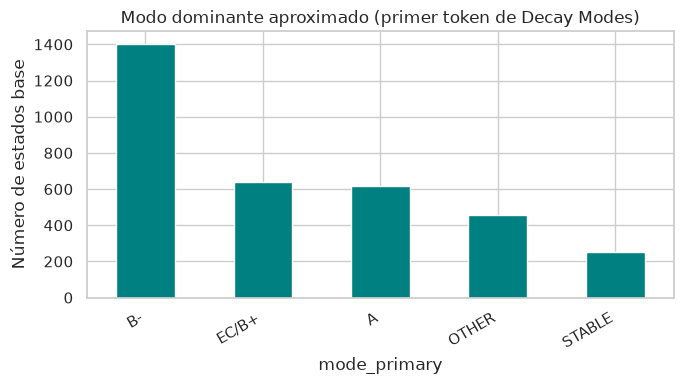

In [9]:
def primary_mode_token(raw) -> str:
    if pd.isna(raw) or str(raw).strip() == "":
        return "MISSING"
    first = str(raw).split(",")[0].strip()
    tok = re.split(r"\s*(?:=|~)\s*", first)[0].strip().upper()
    tok = tok.rstrip("?")
    if tok.startswith("B-"):
        return "B-"
    if tok.startswith("EC+B+") or tok in {"EC", "B+"}:
        return "EC/B+"
    if tok in {"A", "ALPHA"} or tok.startswith("A"):
        return "A"
    if tok.startswith("IT"):
        return "IT"
    return "OTHER"

gs = wallet_n[wallet_n["Level Index"] == 0].copy()
gs["mode_primary"] = wallet.loc[gs.index, "Decay Modes"].map(primary_mode_token)
gs["is_stable"] = wallet.loc[gs.index, "Half-Life"].astype(str).str.upper().eq("STABLE")
gs.loc[gs["is_stable"], "mode_primary"] = "STABLE"
gs["N"] = gs["Atomic Mass (A)"] - gs["Atomic Number (Z)"]
gs["N_over_Z"] = gs["N"] / gs["Atomic Number (Z)"].replace(0, np.nan)

mode_counts = gs["mode_primary"].value_counts()
display(mode_counts.to_frame("n_ground_states"))

fig, ax = plt.subplots(figsize=(7, 4))
mode_counts.plot(kind="bar", ax=ax, color="teal")
ax.set_ylabel("Número de estados base")
ax.set_title("Modo dominante aproximado (primer token de Decay Modes)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG / "eda_modos_dominantes.png", dpi=120)
plt.show()


### Interpretación física

Dominan $\beta^-$ y EC/$\beta^+$, como se espera en el chart lejos de $Z$ muy altos (donde crece $\alpha$). Los estables son pocos frente al total de isótopos conocidos: el valle es una franja estrecha.

## 7. Visualizaciones y relaciones físicas

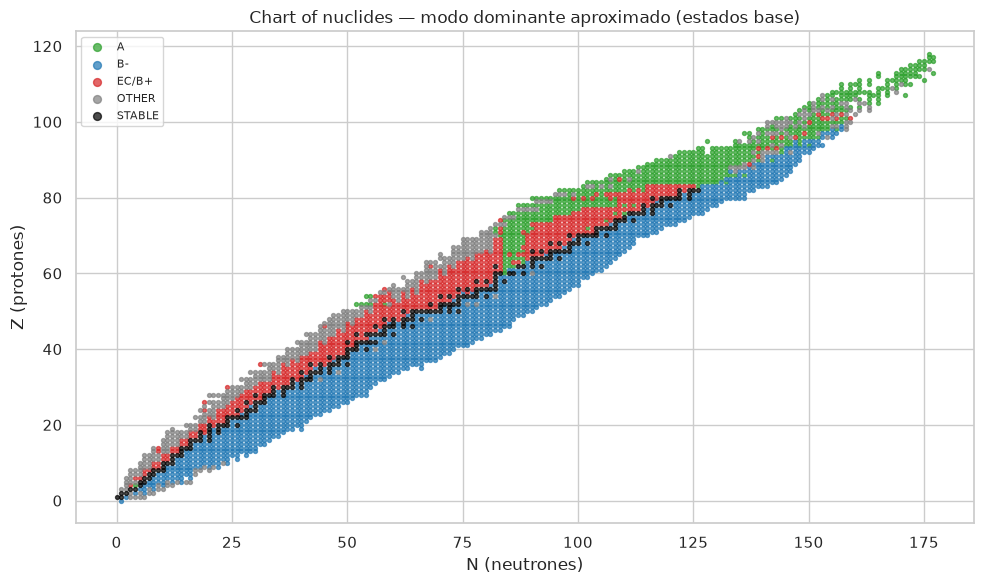

In [10]:
# Chart of nuclides coloreado por modo (exploratorio)
fig, ax = plt.subplots(figsize=(10, 6))
palette = {
    "B-": "#1f77b4",
    "EC/B+": "#d62728",
    "A": "#2ca02c",
    "STABLE": "#000000",
    "IT": "#9467bd",
    "OTHER": "#7f7f7f",
    "MISSING": "#c7c7c7",
}
for mode, sub in gs.groupby("mode_primary"):
    ax.scatter(
        sub["N"], sub["Atomic Number (Z)"],
        s=8, alpha=0.7, label=mode,
        c=palette.get(mode, "#aaaaaa"),
    )
ax.set_xlabel("N (neutrones)")
ax.set_ylabel("Z (protones)")
ax.set_title("Chart of nuclides — modo dominante aproximado (estados base)")
ax.legend(markerscale=2, fontsize=8, frameon=True)
plt.tight_layout()
plt.savefig(FIG / "eda_chart_modos.png", dpi=130)
plt.show()


### Interpretación

Se ve la separación clásica: **rico en neutrones → $\beta^-$** (azul, a la derecha del valle) y **deficiente en neutrones → EC/$\beta^+$** (rojo, a la izquierda). Los estables (negro) siguen la diagonal del valle; $\alpha$ aparece hacia $Z$ altos.

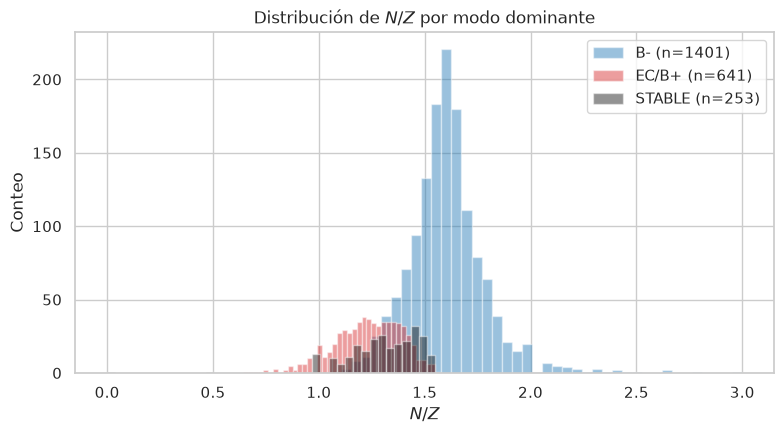

,count,mean,median,std
mode_primary,,,,
A,618,1.387,1.413,0.126
B-,1401,1.605,1.596,0.187
EC/B+,641,1.233,1.244,0.158
OTHER,457,1.192,1.101,0.543
STABLE,253,1.306,1.319,0.174


In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for mode, color in [("B-", "#1f77b4"), ("EC/B+", "#d62728"), ("STABLE", "#111111")]:
    sub = gs[gs["mode_primary"] == mode]["N_over_Z"].dropna()
    ax.hist(sub, bins=40, alpha=0.45, label=f"{mode} (n={len(sub)})", color=color)
ax.set_xlabel("$N/Z$")
ax.set_ylabel("Conteo")
ax.set_title("Distribución de $N/Z$ por modo dominante")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "eda_NZ_por_modo.png", dpi=120)
plt.show()

gs.groupby("mode_primary")["N_over_Z"].agg(["count", "mean", "median", "std"]).round(3)


In [12]:
# Join exploratorio (Z,N) para Q y BE — sin deduplicar aún, solo overlap
gs_zn = gs.rename(columns={"Atomic Number (Z)": "z", "Atomic Mass (A)": "A"})
gs_zn["n"] = gs_zn["N"]

qbe_dedup = qbe_n.drop_duplicates(["z", "n"], keep="first")
hl_dedup = hl_n.drop_duplicates(["z", "n"], keep="first")

expl = gs_zn.merge(qbe_dedup, on=["z", "n"], how="left", suffixes=("", "_q"))
expl = expl.merge(hl_dedup, on=["z", "n"], how="left")

print("Estados base:", len(gs_zn))
print("Con BE/A:", expl["bindingEnergy"].notna().sum())
print("Con Qβ-:", expl["betaMinus"].notna().sum())
print("Con half-life chart (s):", expl["halflife(Seconds)"].notna().sum())


Estados base: 3371
Con BE/A: 3358
Con Qβ-: 3146
Con half-life chart (s): 2897


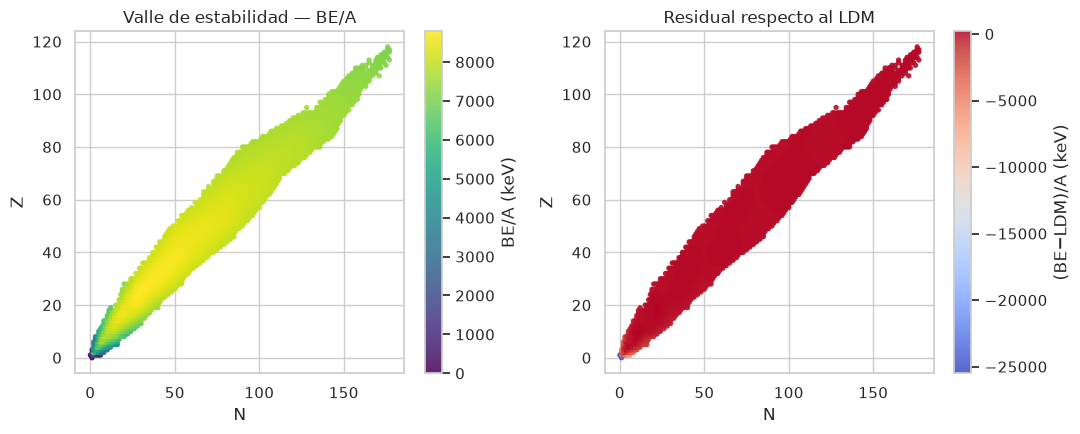

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sc = axes[0].scatter(
    expl["n"], expl["z"],
    c=expl["bindingEnergy"], s=8, cmap="viridis", alpha=0.85,
)
plt.colorbar(sc, ax=axes[0], label="BE/A (keV)")
axes[0].set_xlabel("N"); axes[0].set_ylabel("Z")
axes[0].set_title("Valle de estabilidad — BE/A")

sc2 = axes[1].scatter(
    expl["n"], expl["z"],
    c=expl["bindingEnergyLDMFit"], s=8, cmap="coolwarm", alpha=0.85,
)
plt.colorbar(sc2, ax=axes[1], label="(BE−LDM)/A (keV)")
axes[1].set_xlabel("N"); axes[1].set_ylabel("Z")
axes[1].set_title("Residual respecto al LDM")

plt.tight_layout()
plt.savefig(FIG / "eda_valle_BE_LDM.png", dpi=130)
plt.show()


### Interpretación

- BE/A es máximo cerca de $A\sim 56$–62 (región del hierro) y cae hacia núcleos muy ligeros o muy pesados: firma del valle.
- El residual LDM resalta estructura de capas / magia más allá de la gota líquida.

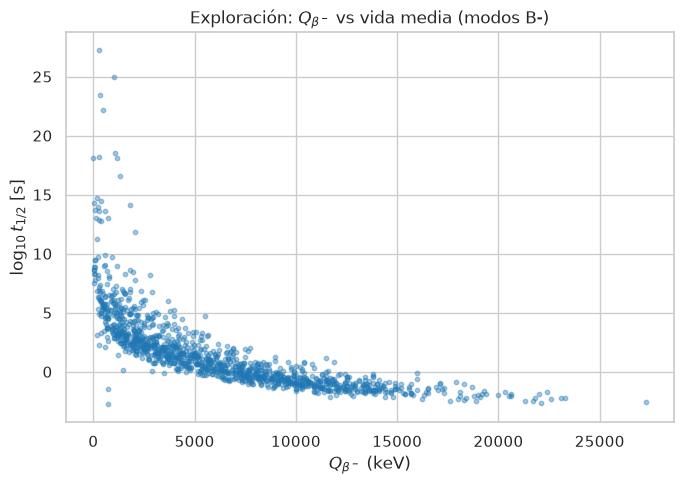

n puntos: 1220
Correlación Pearson Qβ− vs log10 t1/2: -0.709


In [14]:
# Qβ vs log vida media (solo β−)
beta = expl[(expl["mode_primary"] == "B-") & expl["betaMinus"].notna() & expl["halflife(Seconds)"].notna()].copy()
beta = beta[beta["halflife(Seconds)"] > 0]
beta["log10_t12"] = np.log10(beta["halflife(Seconds)"])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(beta["betaMinus"], beta["log10_t12"], s=10, alpha=0.4, c="#1f77b4")
ax.set_xlabel("$Q_{\beta^-}$ (keV)")
ax.set_ylabel("$\log_{10} t_{1/2}$ [s]")
ax.set_title("Exploración: $Q_{\beta^-}$ vs vida media (modos B-)")
plt.tight_layout()
plt.savefig(FIG / "eda_Qb_vs_halflife.png", dpi=120)
plt.show()

print("n puntos:", len(beta))
print("Correlación Pearson Qβ− vs log10 t1/2:",
      beta[["betaMinus", "log10_t12"]].corr().iloc[0, 1].round(3))


### Interpretación

Se observa tendencia a **menor vida media cuando $Q_{\beta^-}$ es mayor** (correlación negativa con $\log t_{1/2}$), coherente con la fase espacial / teoría de Fermi, con mucha dispersión por estructura nuclear (matriz de transición, forbiddenness, etc.).

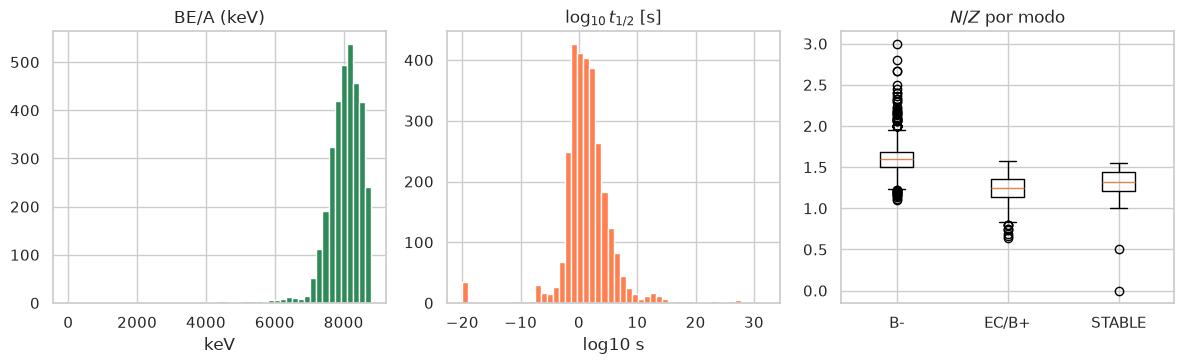

BE/A < 1000 keV (muy ligados? o ligeros): 4
BE/A == 0: 2
Qβ− < 0 (canal cerrado / convención): 1686


In [15]:
# Distribuciones / posibles atípicos
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
axes[0].hist(expl["bindingEnergy"].dropna(), bins=50, color="seagreen")
axes[0].set_title("BE/A (keV)"); axes[0].set_xlabel("keV")

axes[1].hist(np.log10(hl_dedup["halflife(Seconds)"].dropna().clip(lower=1e-20)), bins=50, color="coral")
axes[1].set_title("$\log_{10} t_{1/2}$ [s]"); axes[1].set_xlabel("log10 s")

axes[2].boxplot(
    [expl.loc[expl["mode_primary"] == m, "N_over_Z"].dropna() for m in ["B-", "EC/B+", "STABLE"]],
    tick_labels=["B-", "EC/B+", "STABLE"],
)
axes[2].set_title("$N/Z$ por modo")

plt.tight_layout()
plt.savefig(FIG / "eda_distribuciones.png", dpi=120)
plt.show()

# Candidatos a atípicos: BE/A extremo o Q negativos grandes
print("BE/A < 1000 keV (muy ligados? o ligeros):", (expl["bindingEnergy"] < 1000).sum())
print("BE/A == 0:", (expl["bindingEnergy"] == 0).sum())
print("Qβ− < 0 (canal cerrado / convención):", (expl["betaMinus"] < 0).sum())


### Atípicos / decisiones para la limpieza (siguiente etapa)

| Hallazgo | Acción prevista |
|----------|-----------------|
| Unidades mixtas de $t_{1/2}$ | Convertir a segundos; `STABLE` → flag |
| Duplicados $(Z,N)$ en Chart | `drop_duplicates(keep="first")` |
| Columnas vacías export 21 | No usar spin/mass/Sn/Sp de ese archivo |
| Resonancias (solo decay width) | Excluir o marcar aparte del análisis de $t_{1/2}$ |
| $Q$ negativos | Conservar; filtrar $Q>0$ solo al correlacionar con vidas medias |
| Isómeros | Análisis de valle/modos en **Level Index = 0** |

**Nota:** no hay serie temporal que analizar.

## 8. Conclusiones de la exploración

1. Los cuatro CSV son coherentes en cobertura $(Z,N)$ y permiten abordar la pregunta ($N/Z$–modo, $Q$–$t_{1/2}$, valle BE/A).
2. Wallet aporta **modos y estados**; Chart aporta **Q, BE/A y $t_{1/2}$ en segundos**.
3. Ya se observa físicamente: separación $\beta^-$ / EC+$\beta^+$ en el chart, valle en BE/A, y tendencia $Q_{\beta^-}\uparrow \Rightarrow t_{1/2}\downarrow$.
4. La siguiente etapa es **limpieza + join reproducible** → `data/processed/` (notebook `02_clean_etl.ipynb`).